# Notebook 02 — Mô hình Học sâu Bi-directional LSTM

**Mục tiêu:** Xây dựng và huấn luyện mạng Nơ-ron Bi-LSTM cho bài toán Phân tích Cảm xúc:
1. Xây dựng từ điển từ vựng (Vocabulary) từ tập Train
2. Mã hóa văn bản thành chuỗi token ID & padding (L=100)
3. Định nghĩa kiến trúc **Bidirectional LSTM** với Spatial Dropout và Global Average Pooling
4. Tính toán **Class Weights** để xử lý mất cân bằng dữ liệu
5. Huấn luyện với cơ chế **Early Stopping** chống quá khớp
6. Đánh giá trên tập Test & vẽ Ma trận nhầm lẫn

> **Yêu cầu tiên quyết:** Đã chạy `00_Tien_Xu_Ly.ipynb`.

In [ ]:
# ===== CÀI ĐẶT THƯ VIỆN =====
# !pip install torch pandas scikit-learn matplotlib seaborn


In [1]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Đặt seed để đảm bảo tính tái lập (Reproducibility)
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Chọn thiết bị tính toán (GPU ưu tiên, sau đó MPS cho Mac M1/M2, cuối cùng CPU)
device = torch.device('cuda' if torch.cuda.is_available() else
                      ('mps' if torch.backends.mps.is_available() else 'cpu'))

FN_DIR  = "../fn"
PKL_DIR = "../pkl"
IMG_DIR = "../image"
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print(f"Import thành công! Thiết bị sử dụng: {device}")


Import thành công! Thiết bị sử dụng: mps


## 1. Nạp Dữ liệu

In [2]:
print("Đang nạp dữ liệu...")
train_df = pd.read_csv(os.path.join(FN_DIR, "cleaned_train.csv")).fillna('')
val_df   = pd.read_csv(os.path.join(FN_DIR, "cleaned_validation.csv")).fillna('')
test_df  = pd.read_csv(os.path.join(FN_DIR, "cleaned_test.csv")).fillna('')

X_train_raw, y_train_raw = train_df['comment_cleaned'].values, train_df['label'].values
X_val_raw,   y_val_raw   = val_df['comment_cleaned'].values,   val_df['label'].values
X_test_raw,  y_test_raw  = test_df['comment_cleaned'].values,  test_df['label'].values

print(f"Train: {len(X_train_raw):,} | Validation: {len(X_val_raw):,} | Test: {len(X_test_raw):,}")


Đang nạp dữ liệu...
Train: 11,426 | Validation: 1,583 | Test: 3,166


## 2. Xây dựng Từ điển Từ vựng (Vocabulary)

In [3]:
# Đếm tần suất xuất hiện của từng từ trong tập Train
words = []
for text in X_train_raw:
    words.extend(str(text).split())
word_counts = Counter(words)

# Chỉ giữ các từ xuất hiện >= 2 lần để lọc nhiễu (từ lỗi chính tả ngẫu nhiên)
filtered_words = [w for w, cnt in word_counts.items() if cnt >= 2]
vocab = {word: idx + 2 for idx, word in enumerate(filtered_words)}
vocab['<PAD>'] = 0   # Ký hiệu đệm (padding)
vocab['<UNK>'] = 1   # Ký hiệu từ không có trong từ điển

vocab_size = len(vocab)
print(f"Kích thước từ điển: {vocab_size:,} từ")

# Lưu từ điển để dùng cho bước dự đoán
vocab_path = os.path.join(PKL_DIR, "lstm_vocab.json")
with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False)
print(f"Đã lưu từ điển → {vocab_path}")


Kích thước từ điển: 2,080 từ
Đã lưu từ điển → ../pkl/lstm_vocab.json


## 3. Mã hóa & Padding Chuỗi Văn bản

In [4]:
MAX_LEN = 100  # Độ dài tối đa mỗi chuỗi (token)

def text_to_sequence(text, vocab, max_len=MAX_LEN):
    """Chuyển văn bản thành chuỗi token ID, padding hoặc cắt về độ dài max_len."""
    tokens = str(text).split()
    seq = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    if len(seq) < max_len:
        seq = seq + [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

# Chuyển đổi toàn bộ 3 tập dữ liệu
print("Đang mã hóa văn bản...")
X_train_seq = np.array([text_to_sequence(t, vocab) for t in X_train_raw])
X_val_seq   = np.array([text_to_sequence(t, vocab) for t in X_val_raw])
X_test_seq  = np.array([text_to_sequence(t, vocab) for t in X_test_raw])

# Tạo DataLoader (phân lô dữ liệu)
BATCH_SIZE = 64
def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train_seq, y_train_raw, shuffle=True)
val_loader   = make_loader(X_val_seq,   y_val_raw)
test_loader  = make_loader(X_test_seq,  y_test_raw)

print(f"Đã tạo DataLoader | Shape Train: {X_train_seq.shape}")


Đang mã hóa văn bản...
Đã tạo DataLoader | Shape Train: (11426, 100)


## 4. Định nghĩa Kiến trúc Mô hình Bi-LSTM

In [5]:
class BiLSTMClassifier(nn.Module):
    """
    Kiến trúc mạng Bi-directional LSTM cho bài toán phân loại văn bản.
    
    Cấu trúc:
    Embedding → Spatial Dropout → Bi-LSTM → Global Average Pooling
    → Dropout → FC(256) → ReLU → Dropout → FC(3)
    """
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_classes=3):
        super(BiLSTMClassifier, self).__init__()
        self.embedding      = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.spatial_dropout = nn.Dropout2d(0.2)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True  # → kích thước đầu ra = hidden_dim * 2
        )
        self.lstm_dropout = nn.Dropout(0.2)
        self.fc1     = nn.Linear(hidden_dim * 2, 64)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(64, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                          # (B, L, E)
        # Spatial Dropout: dropout theo chiều feature
        emb = emb.permute(0, 2, 1).unsqueeze(3)
        emb = self.spatial_dropout(emb)
        emb = emb.squeeze(3).permute(0, 2, 1)           # (B, L, E)
        lstm_out, _ = self.lstm(emb)                     # (B, L, 2H)
        out = torch.mean(lstm_out, dim=1)                # Global Average Pooling
        out = self.lstm_dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Khởi tạo mô hình
model = BiLSTMClassifier(vocab_size=vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Khởi tạo mô hình Bi-LSTM thành công!")
print(f"Tổng số tham số: {total_params:,}")


Khởi tạo mô hình Bi-LSTM thành công!
Tổng số tham số: 547,075


## 5. Tính toán Class Weights & Thiết lập Huấn luyện

In [6]:
# Tính Class Weights tỷ lệ nghịch với tần suất xuất hiện của từng lớp
# → Mô hình sẽ bị phạt nặng hơn khi đoán sai lớp thiểu số (Trung tính)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_raw), y=y_train_raw)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

label_map = {0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"}
print("Class Weights (phạt tỷ lệ nghịch với số mẫu):")
for i, (lbl, w) in enumerate(zip(label_map.values(), class_weights)):
    print(f"  Lớp {i} ({lbl}): {w:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Class Weights (phạt tỷ lệ nghịch với số mẫu):
  Lớp 0 (Tiêu cực): 0.7152
  Lớp 1 (Trung tính): 8.3159
  Lớp 2 (Tích cực): 0.6749


## 6. Vòng lặp Huấn luyện với Early Stopping

In [8]:
EPOCHS  = 10
PATIENCE = 3

best_val_loss   = float('inf')
patience_counter = 0
model_path      = os.path.join(PKL_DIR, "best_lstm_model_correct.pth")

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=" * 75)
print("BẮT ĐẦU HUẤN LUYỆN BI-LSTM")
print("=" * 75)

for epoch in range(EPOCHS):
    # --- Training phase ---
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * X_b.size(0)
        t_correct += (torch.max(out, 1)[1] == y_b).sum().item()
        t_total   += y_b.size(0)

    # --- Validation phase ---
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out  = model(X_b)
            loss = criterion(out, y_b)
            v_loss    += loss.item() * X_b.size(0)
            v_correct += (torch.max(out, 1)[1] == y_b).sum().item()
            v_total   += y_b.size(0)

    t_loss /= len(train_loader.dataset)
    v_loss /= len(val_loader.dataset)
    t_acc   = t_correct / t_total
    v_acc   = v_correct / v_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc * 100)
    history['val_acc'].append(v_acc * 100)

    marker = ""
    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        marker = " ← lưu best model"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping tại epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc*100:.2f}% | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc*100:.2f}%{marker}")

print(f"\nĐã lưu best model → {model_path}")


BẮT ĐẦU HUẤN LUYỆN BI-LSTM
Epoch 01/10 | Train Loss: 0.8033 Acc: 73.19% | Val Loss: 0.7355 Acc: 69.05% ← lưu best model
Epoch 02/10 | Train Loss: 0.7068 Acc: 73.60% | Val Loss: 0.7016 Acc: 76.56% ← lưu best model
Epoch 03/10 | Train Loss: 0.6350 Acc: 78.13% | Val Loss: 0.6390 Acc: 83.51% ← lưu best model
Epoch 04/10 | Train Loss: 0.6020 Acc: 81.41% | Val Loss: 0.6154 Acc: 83.64% ← lưu best model
Epoch 05/10 | Train Loss: 0.5397 Acc: 84.78% | Val Loss: 0.5752 Acc: 82.69% ← lưu best model
Epoch 06/10 | Train Loss: 0.5103 Acc: 84.89% | Val Loss: 0.6153 Acc: 82.50%
Epoch 07/10 | Train Loss: 0.4693 Acc: 84.75% | Val Loss: 0.5591 Acc: 85.09% ← lưu best model
Epoch 08/10 | Train Loss: 0.4154 Acc: 86.51% | Val Loss: 0.5812 Acc: 83.13%
Epoch 09/10 | Train Loss: 0.3702 Acc: 87.02% | Val Loss: 0.6076 Acc: 88.06%
Early stopping tại epoch 10

Đã lưu best model → ../pkl/best_lstm_model_correct.pth


## 7. Vẽ Đường cong Học tập

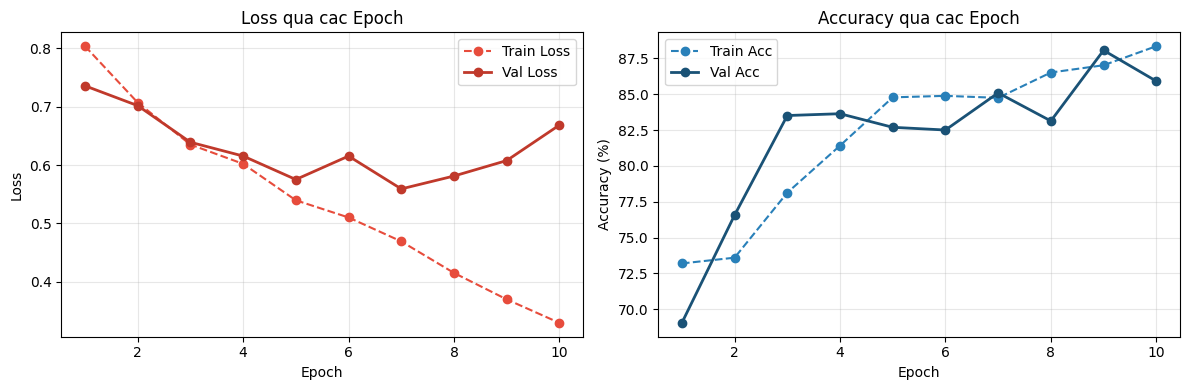

Đã lưu đường cong học tập → ../image/lstm_learning_curve.png


In [9]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], 'o--', label='Train Loss', color='#e74c3c')
ax1.plot(epochs_ran, history['val_loss'],   'o-',  label='Val Loss',   color='#c0392b', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss qua cac Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_acc'], 'o--', label='Train Acc', color='#2980b9')
ax2.plot(epochs_ran, history['val_acc'],   'o-',  label='Val Acc',   color='#1a5276', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy qua cac Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "lstm_learning_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu đường cong học tập → ../image/lstm_learning_curve.png")


## 8. Đánh giá trên Tập Kiểm thử (Test Set)

In [10]:
# Tải lại trọng số tốt nhất
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b.to(device))
        all_preds.extend(torch.max(out, 1)[1].cpu().numpy())
        all_labels.extend(y_b.numpy())

label_names = ['Tieu cuc (0)', 'Trung tinh (1)', 'Tich cuc (2)']
print(f"Test Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print()
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))


Test Accuracy: 83.67%

                precision    recall  f1-score   support

  Tieu cuc (0)     0.8928    0.8573    0.8747      1409
Trung tinh (1)     0.2493    0.5389    0.3409       167
  Tich cuc (2)     0.9304    0.8497    0.8882      1590

      accuracy                         0.8367      3166
     macro avg     0.6909    0.7487    0.7013      3166
  weighted avg     0.8778    0.8367    0.8534      3166



## 9. Ma trận Nhầm lẫn (Confusion Matrix)

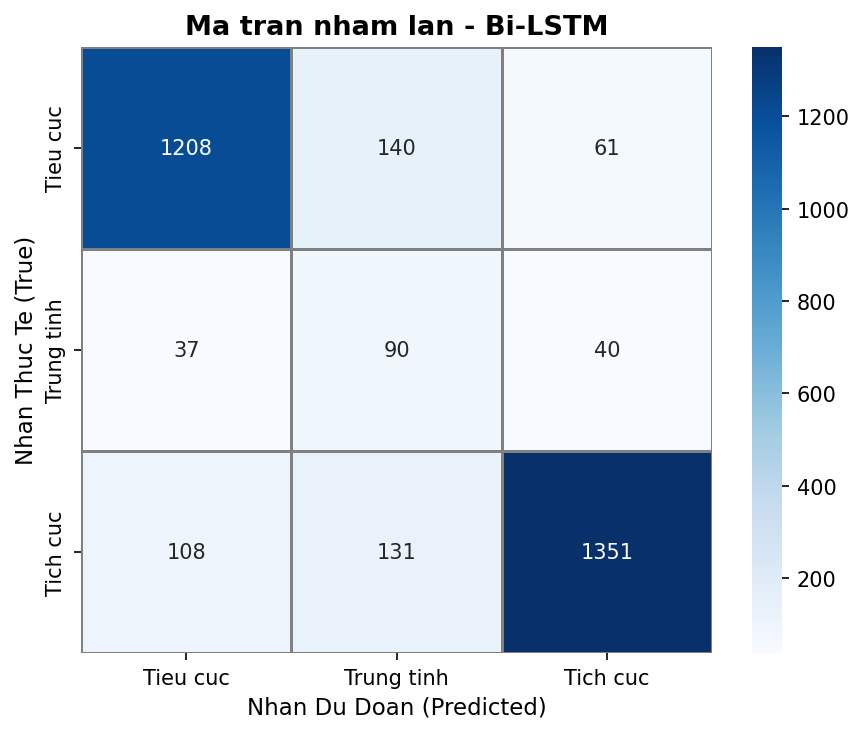

Đã lưu confusion matrix → ../image/cm_lstm.png


In [11]:
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Tieu cuc', 'Trung tinh', 'Tich cuc']

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Nhan Du Doan (Predicted)', fontsize=11)
plt.ylabel('Nhan Thuc Te (True)',      fontsize=11)
plt.title('Ma tran nham lan - Bi-LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cm_lstm.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu confusion matrix → ../image/cm_lstm.png")
